<a href="https://colab.research.google.com/github/pakizahassan/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pakizahassan/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*


### Distribution Review

Before testing any signal, I inspected the distributions of the main search and engagement fields.

The analysis uses page-level March 2026 observations and focuses on public-safe metrics:

- impressions
- clicks
- CTR
- average search position
- sessions
- engagement rate
- scroll activity

Search and traffic metrics are expected to be highly skewed because a relatively small number of pages can receive much more visibility or traffic than the typical page.

For this reason, I report medians and percentiles in addition to averages and use log-scaled visualizations where appropriate.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import userdata
from huggingface_hub import login

login(token=userdata.get("HF_TOKEN"))

columns = [
    "client_hash_id",
    "content_hash_id",
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_sessions",
    "ga4_engaged_sessions",
    "scroll_events"
]

df = pd.read_parquet(
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/"
    "month=2026-03/data_0.parquet",
    columns=columns
)

print("Rows:", len(df))
print("Unique pages:", df["content_hash_id"].nunique())


Rows: 9841378
Unique pages: 331437


## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [3]:
page_df = (
    df.groupby(
        ["client_hash_id", "content_hash_id"],
        observed=True
    )
    .agg(
        impressions=("gsc_impressions", "sum"),
        clicks=("gsc_clicks", "sum"),
        avg_position=("gsc_avg_position", "mean"),
        sessions=("ga4_sessions", "sum"),
        engaged_sessions=("ga4_engaged_sessions", "sum"),
        scroll_events=("scroll_events", "sum")
    )
    .reset_index()
)

page_df["ctr"] = np.where(
    page_df["impressions"] > 0,
    page_df["clicks"] / page_df["impressions"],
    0
)

page_df["engagement_rate"] = np.where(
    page_df["sessions"] > 0,
    page_df["engaged_sessions"] / page_df["sessions"],
    0
)

print("Page-level rows:", len(page_df))

display(page_df.head())


Page-level rows: 331437


,client_hash_id,content_hash_id,impressions,clicks,avg_position,sessions,engaged_sessions,scroll_events,ctr,engagement_rate
0,client_0797ff3a1fc9a6a5,content_004e9c4c32e88631,0,0,NaN,0.0,0.0,0.0,0.0,0.0
1,client_0797ff3a1fc9a6a5,content_0236ef736698e17c,0,0,NaN,0.0,0.0,0.0,0.0,0.0
2,client_0797ff3a1fc9a6a5,content_025f6cfd3c298870,0,0,NaN,0.0,0.0,0.0,0.0,0.0
3,client_0797ff3a1fc9a6a5,content_0263d5f9b7a2ecd4,1,0,9.0,0.0,0.0,0.0,0.0,0.0
4,client_0797ff3a1fc9a6a5,content_02752c6c1c60161f,0,0,NaN,0.0,0.0,0.0,0.0,0.0


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [4]:
distribution_fields = [
    "impressions",
    "clicks",
    "ctr",
    "avg_position",
    "sessions",
    "engagement_rate",
    "scroll_events"
]

distribution_summary = (
    page_df[distribution_fields]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .T
)

display(
    distribution_summary.round(3)
)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
impressions,331437.0,846.790,4044.515,0.0,0.000,2.000,216.000,1707.000,4225.000,14909.280,617124.0
clicks,331437.0,2.480,19.651,0.0,0.000,0.000,0.000,3.000,11.000,47.000,5668.0
ctr,331437.0,0.002,0.028,0.0,0.000,0.000,0.000,0.003,0.006,0.026,1.0
avg_position,176738.0,15.999,17.686,0.0,5.002,8.505,20.369,40.067,56.500,79.759,309.0
sessions,331437.0,3.922,25.382,0.0,0.000,0.000,1.000,4.000,14.000,85.000,2730.0
engagement_rate,331437.0,0.007,0.059,0.0,0.000,0.000,0.000,0.000,0.000,0.200,1.0
scroll_events,331437.0,0.664,4.863,0.0,0.000,0.000,0.000,1.000,3.000,14.000,667.0


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

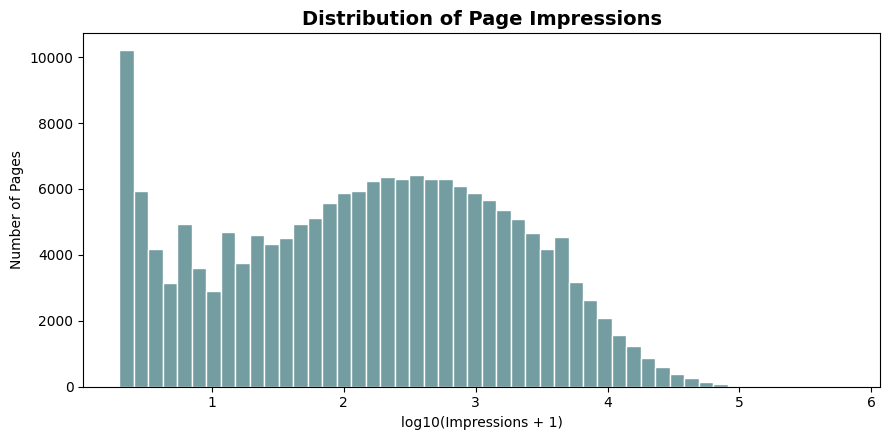

In [5]:
positive_impressions = page_df.loc[
    page_df["impressions"] > 0,
    "impressions"
]

plt.figure(figsize=(9, 4.5))

plt.hist(
    np.log10(positive_impressions + 1),
    bins=50,
    color="#749da1",
    edgecolor="white"
)

plt.title(
    "Distribution of Page Impressions",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("log10(Impressions + 1)")
plt.ylabel("Number of Pages")

plt.tight_layout()
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.